In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('wine_data.csv')

In [4]:
df = df.iloc[: , 0:3]

In [5]:
df.head()

,1,14.23,1.71
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76


In [6]:
df.columns=['class label' , 'alcohol' , 'malic acid']

In [7]:
df

,class label,alcohol,malic acid
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76
...,...,...,...
172,3,13.71,5.65
173,3,13.40,3.91
174,3,13.27,4.28
175,3,13.17,2.59


<Axes: xlabel='alcohol', ylabel='Density'>

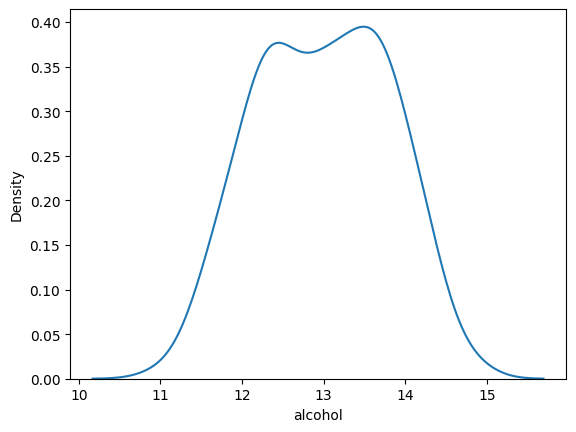

In [8]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='malic acid', ylabel='Density'>

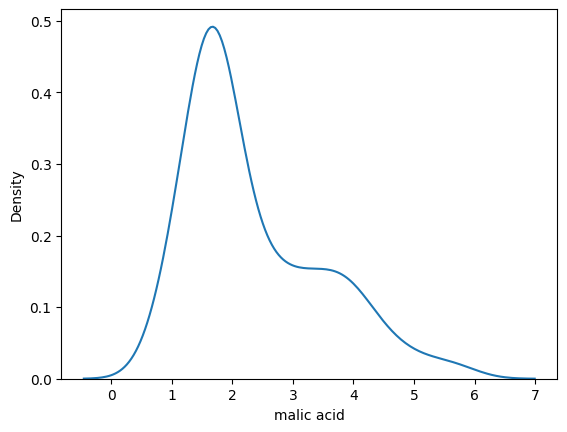

In [9]:
sns.kdeplot(df['malic acid'])

<Axes: xlabel='alcohol', ylabel='malic acid'>

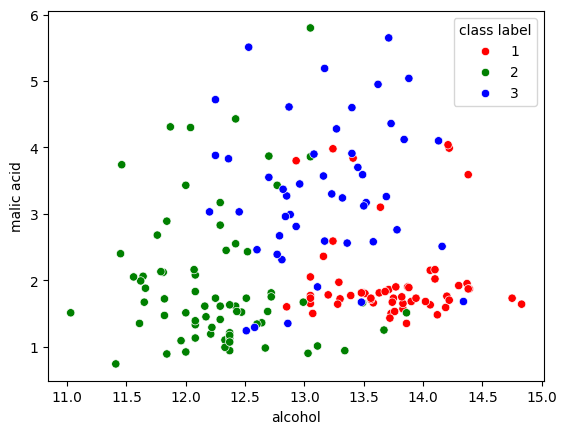

In [16]:
color_dict={1:'red',2:'green',3:'blue'}
sns.scatterplot(
    x=df['alcohol'],
    y=df['malic acid'],
    hue=df['class label'],
    palette=color_dict
)


In [19]:
from sklearn.model_selection import train_test_split as tts

In [21]:
xtr , xts ,ytr ,yts = tts(df[['alcohol','malic acid']] , df['class label'] , random_state=0 , test_size=0.3)

In [22]:
xtr.shape , xts.shape

((123, 2), (54, 2))

In [23]:
from sklearn.preprocessing import MinMaxScaler

In [24]:
scaler=MinMaxScaler()

In [26]:
xtr_scaled=scaler.fit_transform(xtr)

In [27]:
xts_scaled=scaler.transform(xts)

In [30]:
xtr_scaled=pd.DataFrame(xtr_scaled , columns=xtr.columns)

In [34]:
xts_scaled=pd.DataFrame(xts_scaled , columns=xts.columns)

In [36]:
np.round(xtr.describe(),1)

,alcohol,malic acid
count,123.0,123.0
mean,13.0,2.3
std,0.8,1.2
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.8
75%,13.6,3.1
max,14.8,5.8


In [38]:
np.round(xtr_scaled.describe(),1)

,alcohol,malic acid
count,123.0,123.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.1
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


# lets compare by scatterplot and kde plot

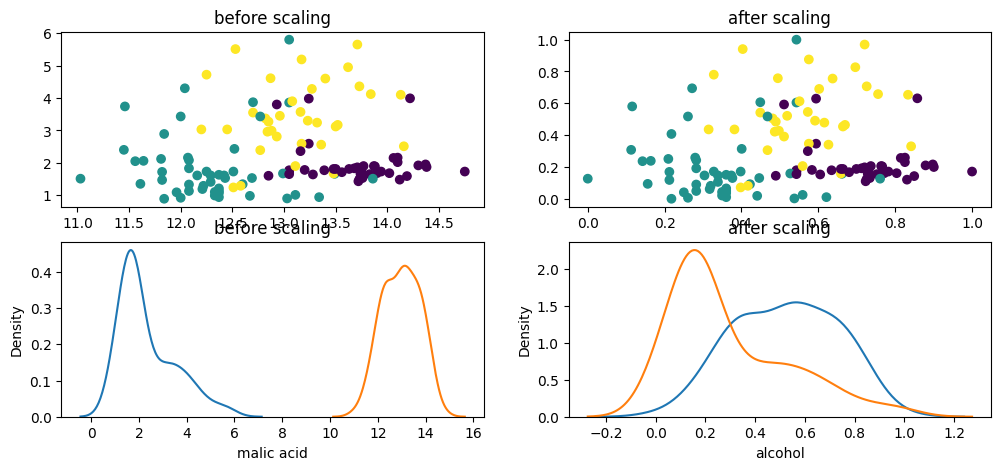

In [46]:
fig,((ax1,ax2) ,( ax3 , ax4) )=plt.subplots(ncols=2 ,nrows=2, figsize=(12,5))

ax1.scatter(xtr['alcohol'] , xtr['malic acid'] , c=ytr)
ax1.set_title('before scaling')

ax2.scatter(xtr_scaled['alcohol'] , xtr_scaled['malic acid'] , c=ytr)
ax2.set_title('after scaling')

sns.kdeplot(xtr['malic acid'] , ax=ax3)
sns.kdeplot(xtr['alcohol'] , ax=ax3)
ax3.set_title('before scaling')

sns.kdeplot(xtr_scaled['alcohol'] , ax=ax4)
sns.kdeplot(xtr_scaled['malic acid'] ,ax=ax4)
ax4.set_title('after scaling')
plt.show()